In [1]:
import matplotlib.pyplot as plt
import numpy as np
import cv2 as cv

--2025-11-18 21:43:29--  https://images.unsplash.com/photo-1624531807109-e70d56c2761a?ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D&auto=format&fit=crop&q=80&w=735
Resolvendo images.unsplash.com (images.unsplash.com)... 2a04:4e42:2a::720, 151.101.178.208
Conectando-se a images.unsplash.com (images.unsplash.com)|2a04:4e42:2a::720|:443... conectado.
A requisição HTTP foi enviada, aguardando resposta... 200 OK
Tamanho: 176342 (172K) [image/jpeg]
Salvando em: ‘teste.jpg’

teste.jpg           100%[===================>] 172,21K  --.-KB/s    em 0,1s    

2025-11-18 21:43:29 (1,49 MB/s) - ‘teste.jpg’ salvo [176342/176342]



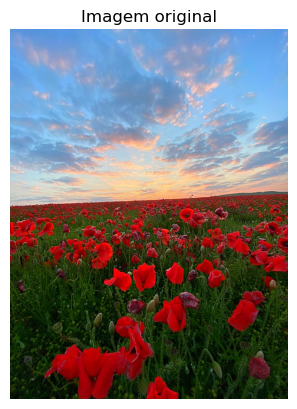

(980, 735, 3)


In [3]:
# Carregamento de uma imagem com OpenCV
#!wget -O 'teste.jpg' 'https://upload.wikimedia.org/wikipedia/commons/f/fd/Pink_flower.jpg'
#!wget -O 'teste.jpg' 'https://us.123rf.com/450wm/seaskylab/seaskylab1010/seaskylab101000037/7972256-campo-de-girassol-amarelo-com-c%C3%A9u-azul-profundo.jpg?ver=6'
!wget -O 'teste.jpg' 'https://images.unsplash.com/photo-1624531807109-e70d56c2761a?ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D&auto=format&fit=crop&q=80&w=735'
image_path='teste.jpg'
image = cv.imread(image_path)

image_RGB = cv.cvtColor(image, cv.COLOR_BGR2RGB)

plt.imshow(image_RGB)
plt.title("Imagem original")
plt.axis('off')
plt.show()
print(image_RGB.shape)

In [4]:
height, width, ch = image_RGB.shape

# Coordenada de exemplo
x_coord, y_coord = 100, 100 # Ponto de exemplo

# Obter valor RGB no ponto escolhido
pixel_value = image_RGB[x_coord, y_coord]
print(f'Coordenadas x={x_coord}, y={y_coord} têm valor RGB: {pixel_value}')


Coordenadas x=100, y=100 têm valor RGB: [132 165 210]


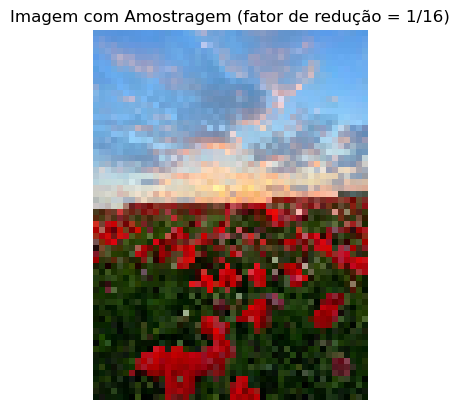

(62, 46, 3)


In [7]:
# Amostragem: Reduzidno a solução da imagem
sampling_factor = 16
small_image = image_RGB[::sampling_factor, ::sampling_factor]

plt.imshow(small_image)
plt.axis('off')
plt.title("Imagem com Amostragem (fator de redução = 1/"+ str(sampling_factor)+")")
plt.show()
print(small_image.shape)

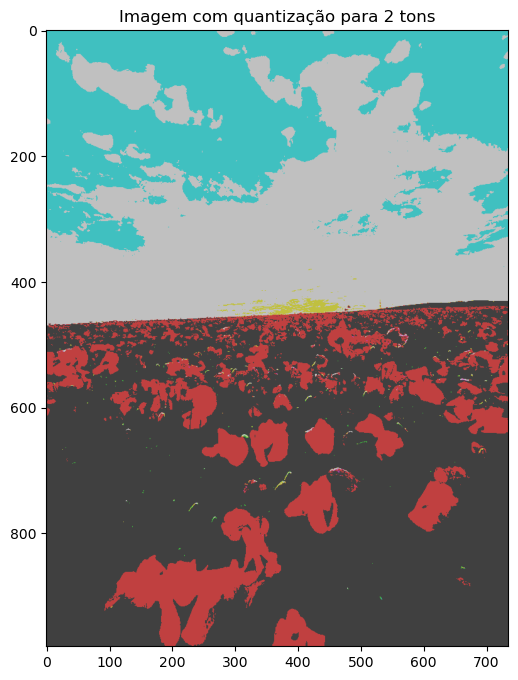

In [9]:
def quantize_image(img, num_colors):
    """
    Realiza quantização de cores na imagem.
    Args:
        img: imagem RGB.
        num_colors: número de tons para quantização.
    Returns:
        Imagem quantizada.
    """
    div_factor = 256 // num_colors # 256 // 2 = 128 logo de 0 a 127 vai ser escuro e 128 a 255
    img_quantized = (img // div_factor) * div_factor + div_factor // 2
    return img_quantized.astype(np.uint8)

num_colors = 2
quantized_image = quantize_image(image_RGB, num_colors)

plt.figure(figsize=(8,8))
plt.imshow(quantized_image)
plt.axis('on')
plt.title(f'Imagem com quantização para {num_colors} tons')
plt.show()

    


O que o código faz visualmente?
Como você definiu num_colors = 2:

O código divide o espectro (0-255) em apenas 2 pedaços:

Escuro (0 a 127)

Claro (128 a 255)

Todo pixel que for "mais ou menos escuro" vira uma única cor cinza escuro.

Todo pixel que for "mais ou menos claro" vira uma única cor cinza claro.

O resultado é uma imagem com alto contraste e pouca definição de degradê, pois você eliminou as transições suaves de cor.

A sua imagem tem o formato (62, 46, 3). Isso significa que ela é um cubo de dados (ou uma matriz 3D):62 pixels de altura (linhas).46 pixels de largura (colunas).3 canais de cor (Vermelho, Verde, Azul) para cada pixel.Total de valores numéricos para processar: $62 \times 46 \times 3 = \mathbf{8.556}$ números.

Quando você faz img // div_factor, o NumPy não tenta dividir a estrutura da imagem. Ele vai em cada um dos 8.556 números individualmente e aplica a divisão, tudo ao mesmo tempo (de forma vetorizada/paralela).

Imagine que estamos olhando para o pixel na posição linha 10, coluna 10. Vamos supor que a cor original dele seja um laranja meio escuro. Os valores RGB originais desse pixel na matriz (62, 46, 3) seriam, por exemplo:

R (Vermelho): 200

G (Verde): 100

B (Azul): 50

3. A Execução da Fórmula
A fórmula é: (img // 128) * 128 + 64

O Python vai aplicar isso nos três canais desse pixel separadamente:

Para o Canal R (Valor 200):

200 // 128 = 1 (Divisão inteira, sobra 72 que é jogado fora).

1 * 128 = 128 (Reconstrução).

128 + 64 = 192 (Ajuste de centro). -> Novo R: 192 (Ficou um vermelho bem vivo).

Para o Canal G (Valor 100):

100 // 128 = 0 (100 é menor que 128).

0 * 128 = 0.

0 + 64 = 64. -> Novo G: 64 (Ficou um verde escuro).

Para o Canal B (Valor 50):

50 // 128 = 0.

0 * 128 = 0.

0 + 64 = 64. -> Novo B: 64 (Ficou um azul escuro).

O Resultado Visual
O pixel que antes era (200, 100, 50) (Laranja detalhado) virou (192, 64, 64) (Um vermelho "padrão" da sua paleta reduzida).

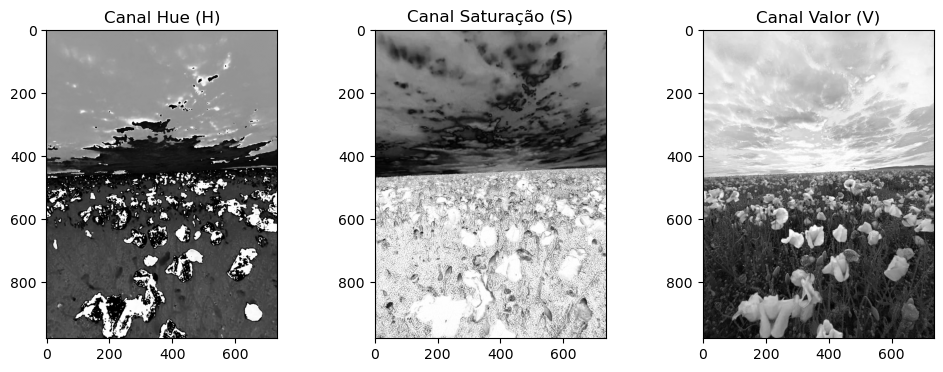

In [11]:
# Converter RGB para HSV e ver os novos canais individualmente
image_hsv = cv.cvtColor(image_RGB, cv.COLOR_RGB2HSV)

# Visualizar componentes HSV separadamente
plt.figure(figsize=(12, 4))

plt.subplot(131)
plt.imshow(image_hsv[:, :, 0], cmap='gray')
plt.title('Canal Hue (H)')

plt.subplot(132)
plt.imshow(image_hsv[:, :, 1], cmap='gray')
plt.title('Canal Saturação (S)')

plt.subplot(133)
plt.imshow(image_hsv[:, :, 2], cmap='gray')
plt.title('Canal Valor (V)')

plt.show()

In [12]:
def adjust_saturation(image_hsv, scale=1.5):
    image_hsv_adjusted = image_hsv.copy()
    image_hsv_adjusted[:,:,1] = np.clip(image_hsv_adjusted[:,:,1] * scale, 0, 255)
    return image_hsv_adjusted.astype(np.uint8)

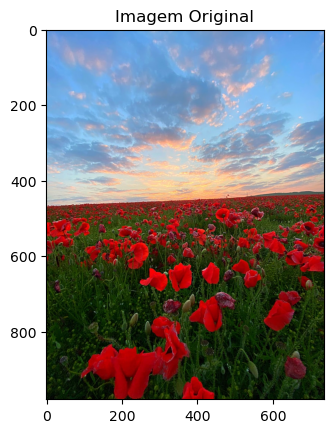

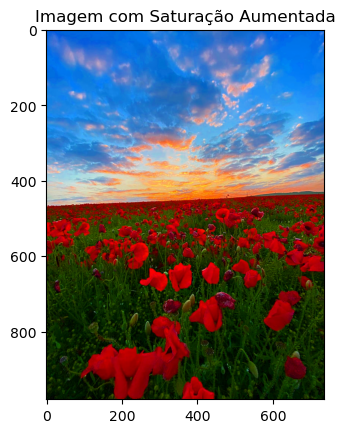

In [13]:
image_hsv_adjusted = adjust_saturation(image_hsv, scale=1.8)

image_rgb_adjusted = cv.cvtColor(image_hsv_adjusted, cv.COLOR_HSV2RGB)

plt.title("Imagem Original")
plt.imshow(image_RGB)
plt.show()
plt.imshow(image_rgb_adjusted)
plt.axis('on')
plt.title("Imagem com Saturação Aumentada")
plt.show()

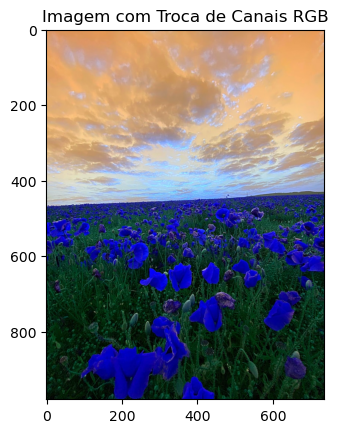

In [14]:
# Trocando os canais R e B para ver o efeito
image_swapped = image_RGB.copy()
image_swapped[:, :, [0, 2]] = image_swapped[:, :, [2, 0]]  # Troca entre R e B

# Visualizar resultado
plt.imshow(image_swapped)
plt.axis('on')
plt.title("Imagem com Troca de Canais RGB")
plt.show()

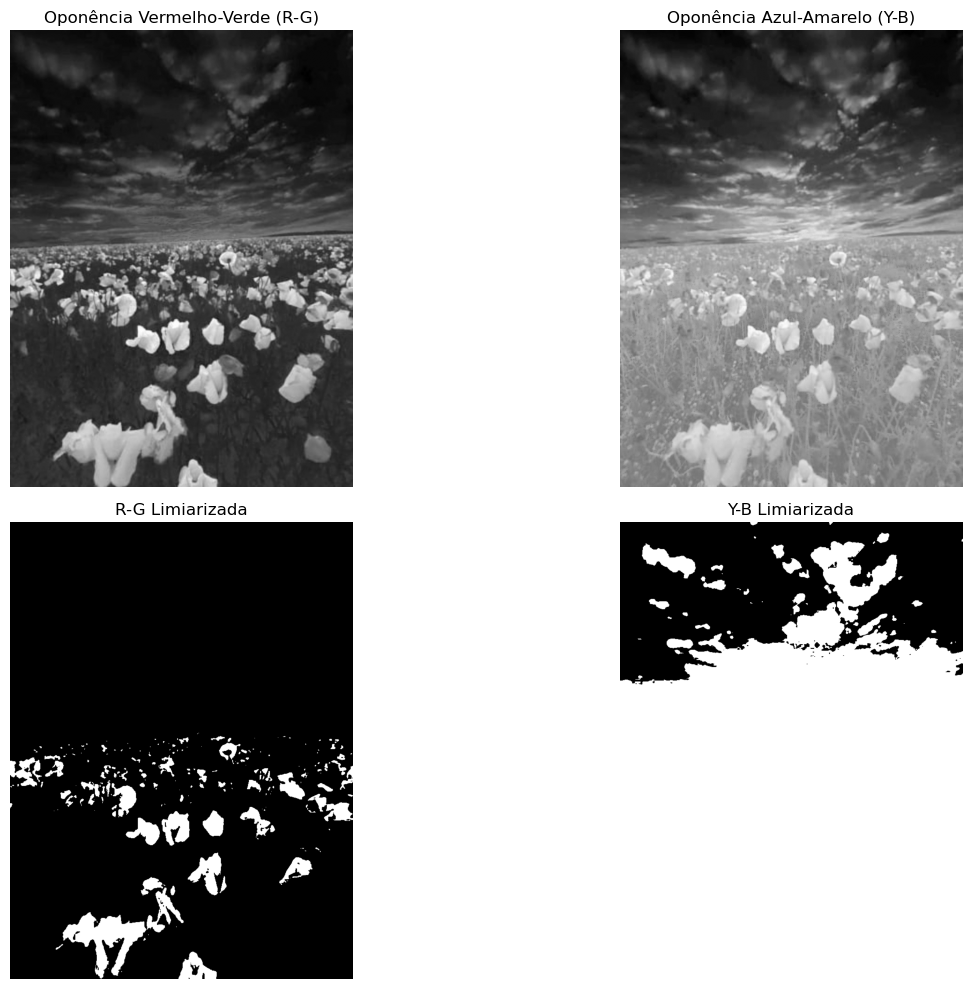

In [15]:
# Extrair canais (garantir tipo float para cáculos)
red_channel = image_RGB[:,:,0].astype(np.float32)
green_channel = image_RGB[:,:,1].astype(np.float32)
blue_channel = image_RGB[:,:, 2].astype(np.float32)

rg_opp = red_channel - green_channel
yellow_approx = (red_channel + green_channel)/2
by_opp = yellow_approx - blue_channel

rg_opp_display = ((rg_opp + 255) / 2).astype(np.uint8)
by_opp_display = ((by_opp + 255)/2).astype(np.uint8)

_, rg_opp_thresh = cv.threshold(rg_opp_display,200,255,cv.THRESH_BINARY)
_, by_opp_thresh = cv.threshold(by_opp_display,100,255,cv.THRESH_BINARY)

plt.figure(figsize=(15, 10))

plt.subplot(221)
plt.imshow(rg_opp_display, cmap='gray')
plt.title('Oponência Vermelho-Verde (R-G)')
plt.axis('off')

plt.subplot(222)
plt.imshow(by_opp_display, cmap='gray')
plt.title('Oponência Azul-Amarelo (Y-B)')
plt.axis('off')

plt.subplot(223)
plt.imshow(rg_opp_thresh, cmap='gray')
plt.title('R-G Limiarizada')
plt.axis('off')

plt.subplot(224)
plt.imshow(by_opp_thresh, cmap='gray')
plt.title('Y-B Limiarizada')
plt.axis('off')

plt.tight_layout()
plt.show()